In [1]:
from matplotlib import pyplot as plt
from scipy.interpolate import CubicSpline
import numpy as np
from UTILS import Verlet_Update, InitialCondition
from scipy.stats import maxwell

In [2]:
class constants:
    mass = 1.6735575e-27 # kg, mass Hbar
    bohr_magneton = 9.2740100657e-24 # J/T, CODATA 2022
    kB = 1.380649e-23   # J/K
    Temperature = 10e-3 # K
    Zmin = -605 # mm
    Zmax = -481 # mm
    Zmid = -544 # mm

CONSTANTS = constants()

# Load Gravity Well

In [3]:
data = np.genfromtxt("Bfield/PreGravity_20mT_well_0g.csv", 
                       delimiter = ",", 
                       names = True, 
                       filling_values=np.nan, 
                       #unpack =  True
                      )
Z = data['\ufeffz_mm__Bz_on_axis']
Uz = data["Total_potential_T__Bz_on_axis"]
print(Z, Uz)
Bfield_20mT_pregravity = CubicSpline(Z, Uz)

data = np.genfromtxt("Bfield/GravityRelease_17mT_well_0g.csv", 
                       delimiter = ",", 
                       names = True, 
                       filling_values=np.nan, 
                       #unpack =  True
                      )
Z = data['\ufeffz_mm__Bz_on_axis']
Uz = data["Total_potential_T__Bz_on_axis"]
print(Z, Uz)
Bfield_17mT = CubicSpline(Z, Uz)

data = np.genfromtxt("Bfield/GravityRelease_5mT_well_0g.csv", 
                       delimiter = ",", 
                       names = True, 
                       filling_values=np.nan, 
                       #unpack =  True
                      )
Z = data['\ufeffz_mm__Bz_on_axis']
Uz = data["Total_potential_T__Bz_on_axis"]
print(Z, Uz)
Bfield_5mT = CubicSpline(Z, Uz)

data = np.genfromtxt("Bfield/GravityRelease_2p5mT_well_0g.csv", 
                       delimiter = ",", 
                       names = True, 
                       filling_values=np.nan, 
                       #unpack =  True
                      )
Z = data['\ufeffz_mm__Bz_on_axis']
Uz = data["Total_potential_T__Bz_on_axis"]
print(Z, Uz)
Bfield_2p5mT = CubicSpline(Z, Uz)

[-3000. -2997. -2994. ...  2994.  2997.  3000.] [-0.00466533 -0.00465643 -0.0046475  ...  0.00595184  0.00595344
  0.00595506]
[-3000. -2997. -2994. ...  2994.  2997.  3000.] [-0.00466541 -0.0046565  -0.00464758 ...  0.00595181  0.00595341
  0.00595504]
[-3000. -2997. -2994. ...  2994.  2997.  3000.] [-0.00466567 -0.00465677 -0.00464784 ...  0.00595172  0.00595332
  0.00595495]
[-3000. -2997. -2994. ...  2994.  2997.  3000.] [-0.00466573 -0.00465683 -0.0046479  ...  0.00595171  0.00595331
  0.00595493]


# Functions to make the plot nicer

In [4]:
# Make Plot Nicer
def plotter_nicer(titlex, titley):
    plt.ylabel(titley, fontsize = 18, loc = "top")
    plt.xlabel(titlex, loc = 'right', fontsize = 18)
    
    plt.grid()
    plt.minorticks_on()
    plt.grid(which='major', linestyle='-', color='black', alpha = 0.5) #Griglia maggiore: linea continua nera
    plt.grid(which='minor', linestyle=':', color='gray') #Griglia minore: linea tratteggiata grigia

def labelfactory(x, y , listlist, labels):
    plt.xticks(labels,[f"{item:.2f}g" for item in labels], rotation = 30)      # etichette

    texts = []
    for xi, yi, label in zip(x, y, listlist):
        texts.append(plt.text(xi - 0.2, yi, label, rotation = 30))
    
    adjust_text(texts, x, y, arrowprops=dict(arrowstyle="->", color='white'))
    
    plt.legend(fontsize = 12)

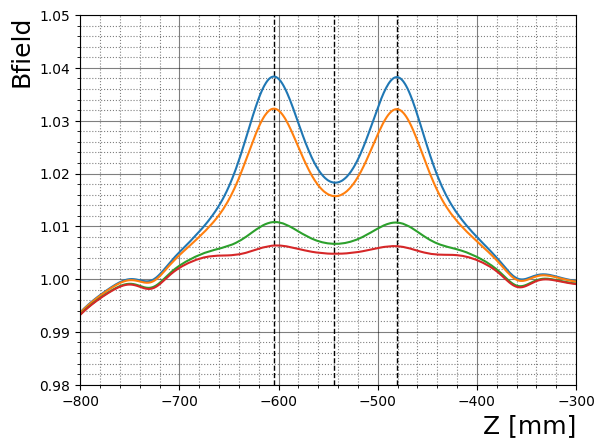

In [5]:
plotter_nicer("Z [mm]", "Bfield")
plt.xlim(-800, -300)
plt.ylim(0.98, 1.05)
plt.axvline(-605, linestyle = "--", color = "black", linewidth = 1)
plt.axvline(-544, linestyle = "--", color = "black", linewidth = 1)
plt.axvline(-481, linestyle = "--", color = "black", linewidth = 1)
plt.plot(Z, Bfield_20mT_pregravity(Z))
plt.plot(Z, Bfield_17mT(Z))
plt.plot(Z, Bfield_5mT(Z))
plt.plot(Z, Bfield_2p5mT(Z))

# Create the 3 segments

In [6]:
# Segment 1,
def segment1(Z,T, ramplength):
    return Bfield_20mT_pregravity(Z) + (Bfield_17mT(Z) - Bfield_20mT_pregravity(Z)) * ( T/ramplength)

# Segment 2,
def segment2(Z,T, ramplength):
    return Bfield_17mT(Z) + (Bfield_5mT(Z) - Bfield_17mT(Z)) * ( T/ramplength)

# Segment 3,
def segment3(Z,T, ramplength):
    return Bfield_5mT(Z) + (Bfield_2p5mT(Z) - Bfield_5mT(Z)) * ( T/ramplength)

# Simulation Setting

In [7]:
nAtoms = 10
Time = 0
Tramp1 = 10
wait_ramp1 = 10
Tramp2 = 10
Tramp3 = 10

## Define variables for visualization

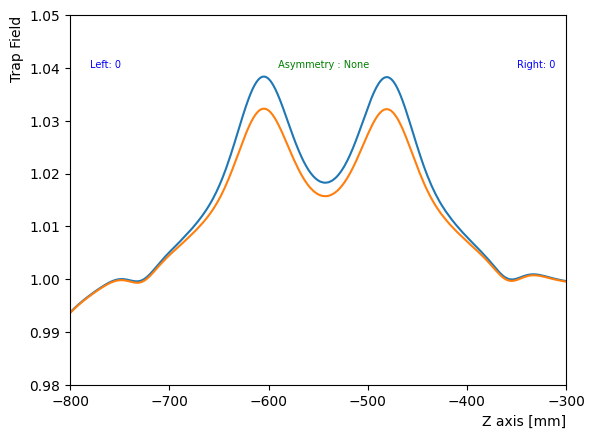

In [8]:
import matplotlib.animation as animation
from matplotlib import rc
from matplotlib import rcParams
from IPython.display import HTML
rc('animation', html='jshtml')   # dice a Matplotlib di rendere l'animazione come HTML/JS

# Imposta il rendering e il limite di embed PRIMA di creare l'animazione
rcParams['animation.html'] = 'jshtml'
rcParams['animation.embed_limit'] = 200.0  # in MB (float)

fig, ax = plt.subplots()

ax.set_xlim(-800, -300)
ax.set_ylim(0.98, 1.05)
ax.set_xlabel("Z axis [mm]", loc = "right")
ax.set_ylabel("Trap Field", loc = "top")

particles_plots = [ax.plot([], [], 'ro', markersize= 2)[0] for _ in range(nAtoms)]  # Palline rosse

# Testo per i contatori
left_count = 0
right_count = 0
asym = None

text_left   = ax.text(-800 + 20,  1.04, f"Left: {left_count}", fontsize=7, color='blue')
text_right  = ax.text(-300 - 50, 1.04, f"Right: {right_count}", fontsize=7, color='blue')
text_center = ax.text(-544 - 50,  1.04, f" Asymmetry : {asym}", fontsize = 7, color = "green")
plt.plot(Z, Bfield_20mT_pregravity(Z))
plt.plot(Z, Bfield_17mT(Z))

## Simulation Test
- **Initialize the particles.**
- **loop to update the particles, verlet velocity.**
- **Define Up and down regions.**

In [ ]:
# Initialize the atoms
atoms = []
for _ in range(nAtoms):
    Vinit, Zinit = InitialCondition(Bfield_20mT_pregravity, CONSTANTS)
    atoms.append({
        "z": Zinit,
        "v": Vinit,
        "free_fall": False
    })

def init():
    for i in range(nAtoms):
        particles_plots[i].set_data([], [])
    text_left.set_text("")
    text_right.set_text("")
    text_center.set_text("")
    
    return particles_plots + [text_left, text_right, text_center]

def update(frame):
    global Time

    if(Time > 0 & Time < Tramp1): # segment 1
        for i, atom in enumerate(atoms): # LOOP on Atoms
    
            Bfield = lambda z: segment1(z, Time, Tramp1)
            Vn, Zn, Tn = Verlet_Update(atom['v'], atom['z'], Time, Bfield, CONSTANTS)
            atom["z"] = Zn
            atom["v"] = Vn
            Time = Tn
            
            particles_plots[i].set_data([atom["z"]],[Bfield(atom["z"])])
            #print(f"particle {Zn} at {Tn}s")

    if(Time > Tramp1 & Time < Tramp1 + wait_ramp1): # wait segment 1
        for i, atom in enumerate(atoms): # LOOP on Atoms
            
            Vn, Zn, Tn = Verlet_Update(atom['v'], atom['z'], Time, Bfield_17mT, CONSTANTS)
            atom["z"] = Zn
            atom["v"] = Vn
            Time = Tn
            
            particles_plots[i].set_data([atom["z"]],[Bfield(atom["z"])])
            #print(f"particle {Zn} at {Tn}s")

    return particles_plots + [text_left, text_right, text_center]

ani = animation.FuncAnimation(
    fig, update,
    init_func=init,  # <-- fondamentale con blit
    frames=2000,
    interval=16,
    blit=True
)

#plt.close(fig)                   # evita la figura statica duplicata
HTML(ani.to_jshtml())            # <-- questo fa apparire l’animazione in JupyterLab

## Simulation